In [36]:
import sys
import cmasher as cmr
import os
# Get the current working directory
current_dir = '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/' #os.getcwd()

# Add the src directory to the Python path
src_path = os.path.join(os.path.dirname(current_dir), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import random
import sys
import os
import cv2
from GridMetrics import GridScorer, circle_mask, get_even_odd_times, GridParameters, create_new_result_dir, load_grid_metrics_from_pickle
import json
import matplotlib
from matplotlib.lines import Line2D
import time

In [37]:
def compute_cell_gs_with_positions(G, cell, x_new, y_new, x_attr="x", y_attr="y"):
    """
    Compute grid score for one cell using TRUE spike times in G,
    but temporarily override positions with x_new / y_new.

    This works for both time shifts and spatial projections.
    """

    # Save original positions from G
    x_orig = getattr(G, x_attr)
    y_orig = getattr(G, y_attr)

    # Scorer attribute names (usually "_x" and "_y")
    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    # Save original positions from Scorer
    scorer_x_orig = getattr(G.Scorer, scorer_x_attr)
    scorer_y_orig = getattr(G.Scorer, scorer_y_attr)

    try:
        # Override positions in BOTH G and its Scorer
        setattr(G, x_attr, x_new)
        setattr(G, y_attr, y_new)

        setattr(G.Scorer, scorer_x_attr, x_new)
        setattr(G.Scorer, scorer_y_attr, y_new)

        # Compute grid score using existing pipeline
        gs = G.compute_cell_grid_score(cell)

    finally:
        # Restore original positions
        setattr(G, x_attr, x_orig)
        setattr(G, y_attr, y_orig)

        setattr(G.Scorer, scorer_x_attr, scorer_x_orig)
        setattr(G.Scorer, scorer_y_attr, scorer_y_orig)

    return gs

In [57]:
def project_positions_along_heading(
    x,
    y,
    D,
    arena_width=1.5,
    arena_height=1.5
):
    """
    Project positions forward or backward by spatial distance D
    along the animal's instantaneous movement direction.

    Returns:
        x_proj: projected x positions
        y_proj: projected y positions
        valid: True for projected samples that remain inside
               the original 1.5 m × 1.5 m environment
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Direction of movement at each time point
    vx = np.diff(x, append=x[-1])
    vy = np.diff(y, append=y[-1])

    theta = np.arctan2(vy, vx)

    # Shift by distance D along heading
    dx = D * np.cos(theta)
    dy = D * np.sin(theta)

    x_proj = x + dx
    y_proj = y + dy

    # Center the fixed 2.2 m × 2.2 m arena on the original environment
    x_center = 0 #(np.nanmin(x) + np.nanmax(x)) / 2
    y_center = 0 #(np.nanmin(y) + np.nanmax(y)) / 2

    x_min = x_center - arena_width / 2
    x_max = x_center + arena_width / 2
    y_min = y_center - arena_height / 2
    y_max = y_center + arena_height / 2

    # Mark projected points that remain inside the arena
    valid = (
        np.isfinite(x_proj) &
        np.isfinite(y_proj) &
        (x_proj >= x_min) &
        (x_proj <= x_max) &
        (y_proj >= y_min) &
        (y_proj <= y_max)
    )

    return x_proj, y_proj, valid

In [58]:
def compute_cell_gs_with_projected_positions(
    G,
    cell,
    D,
    x_attr="x",
    y_attr="y"
):
    """
    Compute grid score after projecting positions by distance D.

    Any projected time point outside the original 2.2 m × 2.2 m
    arena is removed from the position arrays and from every cell's
    aligned spike train.
    """

    # ------------------------------------------------------
    # 1. Original positions
    # ------------------------------------------------------
    x = np.asarray(getattr(G, x_attr), dtype=float)
    y = np.asarray(getattr(G, y_attr), dtype=float)

    # ------------------------------------------------------
    # 2. Project positions and find in-arena samples
    # ------------------------------------------------------
    x_proj, y_proj, valid = project_positions_along_heading(
        x,
        y,
        D,
        arena_width=1.5,
        arena_height=1.5
    )

    valid = np.asarray(valid, dtype=bool)

    if len(valid) != len(x):
        raise ValueError(
            f"Mask length {len(valid)} does not match "
            f"position length {len(x)}."
        )

    if not np.any(valid):
        print(f"Cell {cell}, D={D:.2f}: no valid samples")
        return np.nan

    x_valid = np.asarray(x_proj)[valid]
    y_valid = np.asarray(y_proj)[valid]

    # ------------------------------------------------------
    # 3. Save original data
    # ------------------------------------------------------
    G_x_original = getattr(G, x_attr)
    G_y_original = getattr(G, y_attr)

    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    scorer_x_original = getattr(G.Scorer, scorer_x_attr)
    scorer_y_original = getattr(G.Scorer, scorer_y_attr)

    scorer_spikes_original = G.Scorer._spikes

    # ------------------------------------------------------
    # 4. Crop every cell's binary spike train
    # ------------------------------------------------------
    if not isinstance(scorer_spikes_original, dict):
        raise TypeError(
            "Expected G.Scorer._spikes to be a dictionary."
        )

    scorer_spikes_valid = {}

    for cell_id, spike_train in scorer_spikes_original.items():
        spike_train = np.asarray(spike_train)

        if len(spike_train) != len(valid):
            raise ValueError(
                f"Cell {cell_id} spike length {len(spike_train)} "
                f"does not match position length {len(valid)}."
            )

        scorer_spikes_valid[cell_id] = spike_train[valid]

    # G may also contain its own spike dictionary
    has_G_spikes = hasattr(G, "spikes")
    G_spikes_original = None
    G_spikes_valid = None

    if has_G_spikes and isinstance(G.spikes, dict):
        G_spikes_original = G.spikes
        G_spikes_valid = {}

        for cell_id, spike_train in G_spikes_original.items():
            spike_train = np.asarray(spike_train)

            if len(spike_train) != len(valid):
                raise ValueError(
                    f"G.spikes cell {cell_id} has length "
                    f"{len(spike_train)}, expected {len(valid)}."
                )

            G_spikes_valid[cell_id] = spike_train[valid]

    # ------------------------------------------------------
    # 5. Temporarily use cropped data
    # ------------------------------------------------------
    try:
        setattr(G, x_attr, x_valid)
        setattr(G, y_attr, y_valid)

        setattr(G.Scorer, scorer_x_attr, x_valid)
        setattr(G.Scorer, scorer_y_attr, y_valid)

        G.Scorer._spikes = scorer_spikes_valid

        if G_spikes_valid is not None:
            G.spikes = G_spikes_valid

        # Positions are already installed, so calculate directly
        gs = G.compute_cell_grid_score(cell)

    finally:
        # --------------------------------------------------
        # 6. Restore original data
        # --------------------------------------------------
        setattr(G, x_attr, G_x_original)
        setattr(G, y_attr, G_y_original)

        setattr(G.Scorer, scorer_x_attr, scorer_x_original)
        setattr(G.Scorer, scorer_y_attr, scorer_y_original)

        G.Scorer._spikes = scorer_spikes_original

        if G_spikes_original is not None:
            G.spikes = G_spikes_original

    print(
        f"Cell {cell}, D={D:.2f}: "
        f"kept {valid.sum()} of {len(valid)} samples "
        f"({100 * valid.mean():.1f}%)"
    )

    return gs

In [59]:
rat = "r2"
mod = "1"
exp = "OF"

G_space = GridParameters(rat, mod, exp, precompute=False)

In [84]:
cell = 140
d_values = np.arange(-0.5, 0.52, 0.02)

gs_space = np.full(len(d_values), np.nan)

for i, D in enumerate(d_values):
    print(f"Computing spatial shift D = {D:.2f}")

    gs_space[i] = compute_cell_gs_with_projected_positions(
        G_space,
        cell,
        D
    )

print(gs_space)

Computing spatial shift D = -0.50
Cell 140, D=-0.50: kept 137542 of 238700 samples (57.6%)
Computing spatial shift D = -0.48
Cell 140, D=-0.48: kept 140194 of 238700 samples (58.7%)
Computing spatial shift D = -0.46
Cell 140, D=-0.46: kept 142700 of 238700 samples (59.8%)
Computing spatial shift D = -0.44
Cell 140, D=-0.44: kept 145192 of 238700 samples (60.8%)
Computing spatial shift D = -0.42
Cell 140, D=-0.42: kept 147712 of 238700 samples (61.9%)
Computing spatial shift D = -0.40
Cell 140, D=-0.40: kept 150228 of 238700 samples (62.9%)
Computing spatial shift D = -0.38
Cell 140, D=-0.38: kept 152800 of 238700 samples (64.0%)
Computing spatial shift D = -0.36
Cell 140, D=-0.36: kept 155319 of 238700 samples (65.1%)
Computing spatial shift D = -0.34
Cell 140, D=-0.34: kept 158033 of 238700 samples (66.2%)
Computing spatial shift D = -0.32
Cell 140, D=-0.32: kept 160932 of 238700 samples (67.4%)
Computing spatial shift D = -0.30
Cell 140, D=-0.30: kept 163948 of 238700 samples (68.7%)

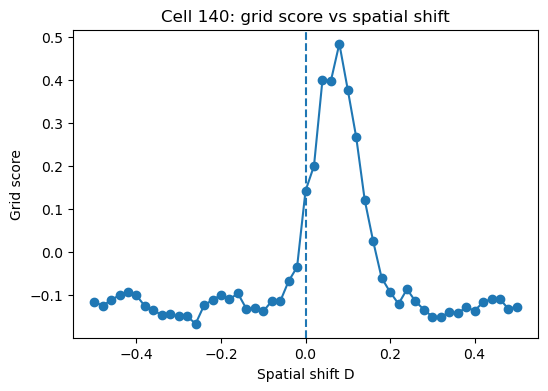

In [85]:
plt.figure(figsize=(6,4))
plt.plot(d_values, gs_space, marker='o')
plt.axvline(0, linestyle='--')
plt.xlabel("Spatial shift D")
plt.ylabel("Grid score")
plt.title(f"Cell {cell}: grid score vs spatial shift")
plt.show()

In [79]:
# Determine number of cells
if hasattr(G_space, "n_cells"):
    n_cells = G_space.n_cells
elif hasattr(G_space.Scorer, "_spikes"):
    n_cells = len(G_space.Scorer._spikes)
else:
    raise ValueError("Could not determine number of cells")

print("Number of cells:", n_cells)

Number of cells: 189


In [86]:
# FIND THE BEST SPATIAL SHIFT FOR ONE CELL

best_idx_space = np.argmax(gs_space)
best_D_space = d_values[best_idx_space]
best_gs_space = gs_space[best_idx_space]

print("Best spatial shift D:", best_D_space)
print("Best spatial grid score:", best_gs_space)
print("Grid score at D=0:", gs_space[np.argmin(np.abs(d_values - 0))])

Best spatial shift D: 0.08000000000000052
Best spatial grid score: 0.48463922299380313
Grid score at D=0: 0.14229220422625583


In [81]:
# ---------------------------------------------
# SPATIAL SHIFT RATEMAP COMPARISON
# ---------------------------------------------

In [89]:
def compute_cell_ratemap_with_projected_positions(
    G,
    cell,
    D,
    x_attr="x",
    y_attr="y",
    arena_width=1.5,
    arena_height=1.5
):
    """
    Compute a ratemap after shifting positions by spatial distance D.

    Any projected time point that falls outside the original
    1.5 m × 1.5 m arena is removed from the position arrays and
    from every aligned spike train before the ratemap is calculated.
    """

    # 1. Original position arrays
    x = np.asarray(getattr(G, x_attr), dtype=float)
    y = np.asarray(getattr(G, y_attr), dtype=float)

    # 2. Project positions and obtain the in-arena mask
    x_proj, y_proj, valid = project_positions_along_heading(
        x,
        y,
        D,
        arena_width=arena_width,
        arena_height=arena_height
    )

    x_proj = np.asarray(x_proj, dtype=float)
    y_proj = np.asarray(y_proj, dtype=float)
    valid = np.asarray(valid, dtype=bool)

    # Basic checks
    if valid.shape != x.shape:
        raise ValueError(
            f"Valid-mask shape {valid.shape} does not match "
            f"position shape {x.shape}."
        )

    if not np.any(valid):
        raise ValueError(
            f"Cell {cell}, D={D:.2f}: "
            "no projected samples remain inside the arena."
        )

    # 3. Remove out-of-arena samples completely
    x_valid = x_proj[valid]
    y_valid = y_proj[valid]

    # 4. Save original position data
    G_x_original = getattr(G, x_attr)
    G_y_original = getattr(G, y_attr)

    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    scorer_x_original = getattr(G.Scorer, scorer_x_attr)
    scorer_y_original = getattr(G.Scorer, scorer_y_attr)

    # 5. Save and crop the scorer spike dictionary
    scorer_spikes_original = G.Scorer._spikes

    if not isinstance(scorer_spikes_original, dict):
        raise TypeError(
            "Expected G.Scorer._spikes to be a dictionary."
        )

    scorer_spikes_valid = {}

    for cell_id, spike_train in scorer_spikes_original.items():
        spike_train = np.asarray(spike_train)

        if len(spike_train) != len(valid):
            raise ValueError(
                f"Cell {cell_id}: spike length {len(spike_train)} "
                f"does not match position length {len(valid)}."
            )

        scorer_spikes_valid[cell_id] = spike_train[valid]

    # 6. G may also store an aligned spike dictionary
    has_G_spikes = (
        hasattr(G, "spikes")
        and isinstance(G.spikes, dict)
    )

    if has_G_spikes:
        G_spikes_original = G.spikes
        G_spikes_valid = {}

        for cell_id, spike_train in G_spikes_original.items():
            spike_train = np.asarray(spike_train)

            if len(spike_train) != len(valid):
                raise ValueError(
                    f"G.spikes cell {cell_id}: spike length "
                    f"{len(spike_train)} does not match "
                    f"position length {len(valid)}."
                )

            G_spikes_valid[cell_id] = spike_train[valid]

    try:
        # 7. Temporarily install cropped positions and spikes
        setattr(G, x_attr, x_valid)
        setattr(G, y_attr, y_valid)

        setattr(G.Scorer, scorer_x_attr, x_valid)
        setattr(G.Scorer, scorer_y_attr, y_valid)

        G.Scorer._spikes = scorer_spikes_valid

        if has_G_spikes:
            G.spikes = G_spikes_valid

        # 8. Calculate the ratemap
        ratemap = G.Scorer.calculate_ratemap(
            cell=cell,
            delta=G.delta
        )

    finally:
        # 9. Restore all original data
        setattr(G, x_attr, G_x_original)
        setattr(G, y_attr, G_y_original)

        setattr(G.Scorer, scorer_x_attr, scorer_x_original)
        setattr(G.Scorer, scorer_y_attr, scorer_y_original)

        G.Scorer._spikes = scorer_spikes_original

        if has_G_spikes:
            G.spikes = G_spikes_original

    print(
        f"Cell {cell}, D={D:.2f}: "
        f"kept {valid.sum()} / {len(valid)} samples "
        f"({100 * valid.mean():.1f}%)"
    )

    return ratemap

Cell 140, D=0.00: kept 238678 / 238700 samples (100.0%)
Cell 140, D=0.08: kept 218256 / 238700 samples (91.4%)
Cell 140, D=-0.08: kept 215647 / 238700 samples (90.3%)
D=0 finite bins: 1331
D=+ finite bins: 1443
D=- finite bins: 1442
[ 6 43]
[ 6 43]
[ 6 43]
Saved to: /Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/results/r21/Spatial shift/cell_140_ratemap.svg


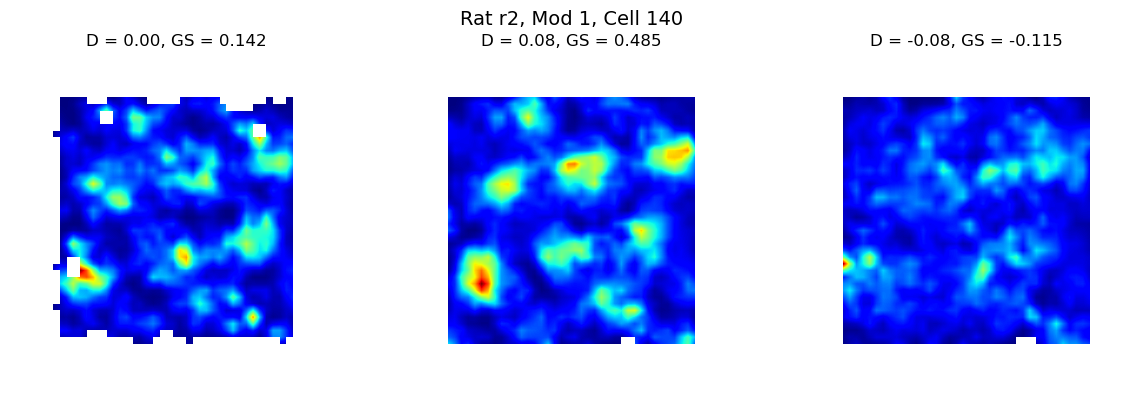

In [91]:
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

# These variables should already exist:
# cell
# G_space
# d_values
# gs_space
# best_D_space
# best_gs_space

# ==========================================================
# RECOMPUTE CROPPED RATEMAPS
# ==========================================================

r_space_0 = compute_cell_ratemap_with_projected_positions(
    G_space,
    cell,
    0.0
)

r_space_best = compute_cell_ratemap_with_projected_positions(
    G_space,
    cell,
    best_D_space
)

r_space_opposite = compute_cell_ratemap_with_projected_positions(
    G_space,
    cell,
    -best_D_space
)

print("D=0 finite bins:", np.sum(np.isfinite(r_space_0)))
print("D=+ finite bins:", np.sum(np.isfinite(r_space_best)))
print("D=- finite bins:", np.sum(np.isfinite(r_space_opposite)))

print(np.where(np.any(np.isfinite(r_space_0), axis=1))[0][[0,-1]])
print(np.where(np.any(np.isfinite(r_space_best), axis=1))[0][[0,-1]])
print(np.where(np.any(np.isfinite(r_space_opposite), axis=1))[0][[0,-1]])

# Grid scores used in the titles
zero_idx = np.argmin(np.abs(d_values))
opposite_idx = np.argmin(
    np.abs(d_values + best_D_space)
)

gs_at_0 = gs_space[zero_idx]
gs_at_opposite = gs_space[opposite_idx]

titles = [
    f"D = 0.00, GS = {gs_at_0:.3f}",
    f"D = {best_D_space:.2f}, GS = {best_gs_space:.3f}",
    f"D = {-best_D_space:.2f}, GS = {gs_at_opposite:.3f}"
]

maps = [
    r_space_0,
    r_space_best,
    r_space_opposite
]

cmap = plt.cm.jet.copy()
cmap.set_bad("white")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, ratemap, title in zip(axes, maps, titles):

    visited = np.isfinite(ratemap)

    ratemap_filled = np.array(ratemap, copy=True)
    ratemap_filled[~visited] = 0.0

    ratemap_smoothed = gaussian_filter(
        ratemap_filled,
        sigma=0.75
    )

    if np.nanmax(ratemap_smoothed) > 0:
        ratemap_smoothed = (
            ratemap_smoothed /
            np.nanmax(ratemap_smoothed)
        )

    ratemap_smoothed[~visited] = np.nan

    ax.imshow(
        ratemap_smoothed,
        cmap=cmap,
        vmin=0,
        vmax=1,
        interpolation="bilinear",
        origin="lower",
        extent=[0, 50, 0, 50],
        aspect="equal"
    )

    ax.set_xlim(0, 50)
    ax.set_ylim(0, 50)

    ax.set_title(title)
    ax.axis("off")

fig.suptitle(
    f"Rat {rat}, Mod {mod}, Cell {cell}",
    fontsize=14
)

plt.tight_layout()

save_path = os.path.expanduser("/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/results/" + rat + mod + "/Spatial shift/cell_" + str(cell) + "_ratemap.svg")


plt.savefig(
    save_path,
    format="svg",
    bbox_inches="tight"
)

print("Saved to:", save_path)

plt.show()

In [95]:
# --------------------------------------------------
# SPATIAL SHIFT SAC FIGURE
# Mirrors the time-shift SAC visualization logic
# --------------------------------------------------

def compute_cell_sac_with_projected_positions(G, cell, D, x_attr="x", y_attr="y"):
    x = np.asarray(getattr(G, x_attr))
    y = np.asarray(getattr(G, y_attr))

    x_proj, y_proj, valid = project_positions_along_heading(x, y, D)

    # Save originals
    x_orig = getattr(G, x_attr)
    y_orig = getattr(G, y_attr)

    scorer_x_attr = "_" + x_attr
    scorer_y_attr = "_" + y_attr

    scorer_x_orig = getattr(G.Scorer, scorer_x_attr)
    scorer_y_orig = getattr(G.Scorer, scorer_y_attr)

    try:
        # Override positions in both G and Scorer
        setattr(G, x_attr, x_proj)
        setattr(G, y_attr, y_proj)
        setattr(G.Scorer, scorer_x_attr, x_proj)
        setattr(G.Scorer, scorer_y_attr, y_proj)

        # Compute ratemap
        R = G.Scorer.calculate_ratemap(cell=cell, delta=G.delta)

        # Compute SAC
        S = G.Scorer.calculate_sac(cell, delta=G.delta)

    finally:
        # Restore originals
        setattr(G, x_attr, x_orig)
        setattr(G, y_attr, y_orig)
        setattr(G.Scorer, scorer_x_attr, scorer_x_orig)
        setattr(G.Scorer, scorer_y_attr, scorer_y_orig)

    return R, S

In [93]:
from matplotlib.colors import LinearSegmentedColormap

parula = LinearSegmentedColormap.from_list(
    "parula",
    [
        (0.2081, 0.1663, 0.5292),
        (0.2116, 0.1898, 0.5777),
        (0.2123, 0.2138, 0.6270),
        (0.2081, 0.2386, 0.6771),
        (0.1959, 0.2647, 0.7279),
        (0.1707, 0.2919, 0.7792),
        (0.1253, 0.3242, 0.8303),
        (0.0591, 0.3598, 0.8683),
        (0.0117, 0.3875, 0.8820),
        (0.0060, 0.4086, 0.8828),
        (0.0165, 0.4266, 0.8786),
        (0.0329, 0.4430, 0.8720),
        (0.0498, 0.4586, 0.8641),
        (0.0629, 0.4737, 0.8554),
        (0.0723, 0.4887, 0.8467),
        (0.0779, 0.5040, 0.8384),
        (0.0793, 0.5200, 0.8312),
        (0.0749, 0.5375, 0.8263),
        (0.0641, 0.5570, 0.8240),
        (0.0488, 0.5772, 0.8228),
        (0.0343, 0.5966, 0.8199),
        (0.0265, 0.6137, 0.8135),
        (0.0239, 0.6287, 0.8038),
        (0.0231, 0.6418, 0.7913),
        (0.0228, 0.6535, 0.7768),
        (0.0267, 0.6642, 0.7607),
        (0.0384, 0.6743, 0.7436),
        (0.0590, 0.6838, 0.7254),
        (0.0843, 0.6928, 0.7062),
        (0.1133, 0.7015, 0.6859),
        (0.1453, 0.7098, 0.6646),
        (0.1801, 0.7177, 0.6424),
        (0.2178, 0.7250, 0.6193),
        (0.2586, 0.7317, 0.5954),
        (0.3022, 0.7376, 0.5712),
        (0.3482, 0.7424, 0.5473),
        (0.3953, 0.7459, 0.5244),
        (0.4420, 0.7481, 0.5033),
        (0.4871, 0.7491, 0.4840),
        (0.5300, 0.7491, 0.4661),
        (0.5709, 0.7485, 0.4494),
        (0.6099, 0.7473, 0.4337),
        (0.6473, 0.7456, 0.4188),
        (0.6834, 0.7435, 0.4044),
        (0.7184, 0.7411, 0.3905),
        (0.7525, 0.7384, 0.3768),
        (0.7858, 0.7356, 0.3633),
        (0.8185, 0.7327, 0.3498),
        (0.8507, 0.7299, 0.3360),
        (0.8824, 0.7274, 0.3217),
        (0.9139, 0.7258, 0.3063),
        (0.9450, 0.7261, 0.2886),
        (0.9739, 0.7314, 0.2666),
        (0.9938, 0.7455, 0.2403),
        (0.9990, 0.7653, 0.2164),
        (0.9955, 0.7861, 0.1967),
        (0.9880, 0.8066, 0.1794),
        (0.9789, 0.8271, 0.1633),
        (0.9697, 0.8481, 0.1475),
        (0.9626, 0.8705, 0.1309),
        (0.9589, 0.8949, 0.1132),
        (0.9598, 0.9218, 0.0948),
        (0.9661, 0.9514, 0.0755),
        (0.9763, 0.9831, 0.0538),
    ],
    N=256
)

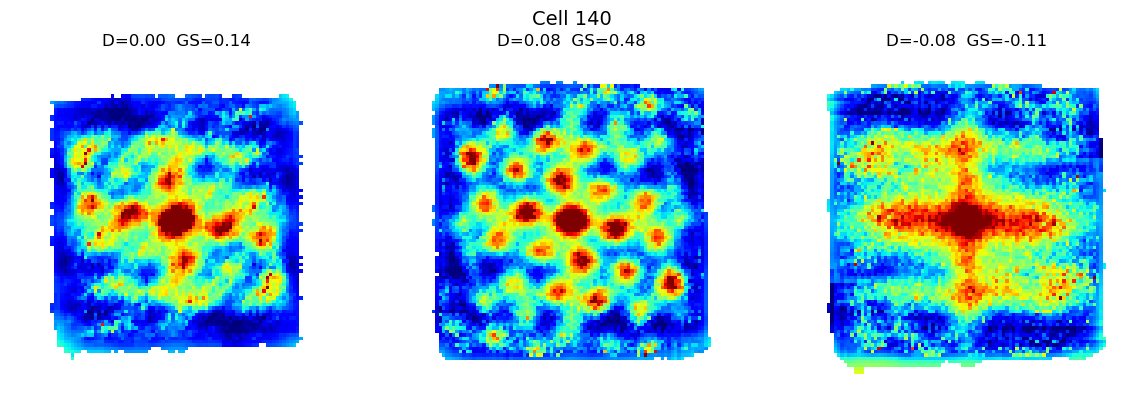

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


# recompute best D for the CURRENT cell
best_idx_space = np.argmax(gs_space)
best_D_space = d_values[best_idx_space]
best_gs_space = gs_space[best_idx_space]

# GS at D = 0
gs_at_0 = gs_space[np.argmin(np.abs(d_values - 0))]

# GS at opposite D
gs_at_opposite = gs_space[np.argmin(np.abs(d_values + best_D_space))]

Ds = [0.0, best_D_space, -best_D_space]
GS_titles = [gs_at_0, best_gs_space, gs_at_opposite]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, D, gs in zip(axes, Ds, GS_titles):
    R, S = compute_cell_sac_with_projected_positions(G_space, cell, D)

    seq = np.nan_to_num(R)
    ones = np.ones(seq.shape)
    ones[np.isnan(R)] = 0

    n_bins = convolve2d(ones, ones, mode="full")

    orig_shape = R.shape
    cx, cy = np.array(n_bins.shape) // 2
    hx, hy = orig_shape
    n_bins = n_bins[cx-hx+1:cx+hx, cy-hy+1:cy+hy]

    threshold = np.nanpercentile(n_bins, 2)
    S_clean = S.copy()
    S_clean[n_bins <= threshold] = np.nan

    S_scale = S_clean.copy()
    cx, cy = np.array(S_scale.shape) // 2
    S_scale[cx-2:cx+3, cy-2:cy+3] = np.nan

    vmin = np.nanpercentile(S_scale, 1)
    vmax = np.nanpercentile(S_scale, 99)

    ax.imshow(
        S_clean,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )
    ax.set_title(f"D={D:.2f}  GS={gs:.2f}")
    ax.axis("off")

fig.suptitle(f"Cell {cell}", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#------------------------------------
# Criterion Checker -> DETERMINING PREDICTIVE CELLS
#------------------------------------

In [98]:
if hasattr(G_space, "n_cells"):
    n_cells = G_space.n_cells
elif hasattr(G_space.Scorer, "_spikes"):
    n_cells = len(G_space.Scorer._spikes)
else:
    raise ValueError("Could not determine number of cells in G_space")

print("Number of cells:", n_cells)

Number of cells: 189


In [ ]:
# ==========================================================
# NEW CRITERION CHECKER: BEST GS MUST BE AT A POSITIVE SHIFT
# ==========================================================
predictive_cells = []

for cell in range(n_cells):
    try:
        gs_space = np.array([
            compute_cell_gs_with_projected_positions(G_space, cell, D)
            for D in d_values
        ])

        # baseline GS
        zero_idx = np.argmin(np.abs(d_values))
        gs_at_0 = gs_space[zero_idx]

        # positive side
        pos_mask = d_values > 0
        pos_gs = gs_space[pos_mask]
        pos_D = d_values[pos_mask]

        best_pos_idx = np.argmax(pos_gs)
        best_pos_gs = pos_gs[best_pos_idx]
        best_pos_D = pos_D[best_pos_idx]

        # negative side
        neg_mask = d_values < 0
        neg_gs = gs_space[neg_mask]

        best_neg_gs = np.max(neg_gs)

        # stricter predictive criterion
        is_predictive = (
            (gs_at_0 < 0.3) and
            (best_pos_gs > 0.3) and
            (best_pos_gs > best_neg_gs + 0.15)
        )

        if is_predictive:
            predictive_cells.append(
                (cell, gs_at_0, best_pos_gs, best_pos_D, best_neg_gs)
            )
    except:
        continue

Cell 0, D=-0.50: kept 137542 of 238700 samples (57.6%)
Cell 0, D=-0.48: kept 140194 of 238700 samples (58.7%)
Cell 0, D=-0.46: kept 142700 of 238700 samples (59.8%)
Cell 0, D=-0.44: kept 145192 of 238700 samples (60.8%)
Cell 0, D=-0.42: kept 147712 of 238700 samples (61.9%)
Cell 0, D=-0.40: kept 150228 of 238700 samples (62.9%)
Cell 0, D=-0.38: kept 152800 of 238700 samples (64.0%)
Cell 0, D=-0.36: kept 155319 of 238700 samples (65.1%)
Cell 0, D=-0.34: kept 158033 of 238700 samples (66.2%)
Cell 0, D=-0.32: kept 160932 of 238700 samples (67.4%)
Cell 0, D=-0.30: kept 163948 of 238700 samples (68.7%)
Cell 0, D=-0.28: kept 166918 of 238700 samples (69.9%)
Cell 0, D=-0.26: kept 169855 of 238700 samples (71.2%)
Cell 0, D=-0.24: kept 173026 of 238700 samples (72.5%)
Cell 0, D=-0.22: kept 176365 of 238700 samples (73.9%)
Cell 0, D=-0.20: kept 179943 of 238700 samples (75.4%)
Cell 0, D=-0.18: kept 183935 of 238700 samples (77.1%)
Cell 0, D=-0.16: kept 188157 of 238700 samples (78.8%)
Cell 0, D=

In [ ]:
print("\nPredictive spatial cells:")

for c in predictive_cells:

    print(
        f"Cell {c[0]} | "
        f"GS(0)={c[1]:.3f} | "
        f"GS(max+)={c[2]:.3f} | "
        f"D={c[3]:.3f} | "
        f"GS(max-)={c[4]:.3f}"
    )

print(f"\nTotal: {len(predictive_cells)}")

In [ ]:
spatial_predictive_grid_cells = np.load(
    os.path.join(
        session_results_directory,
        "spatial_predictive_grid_cells.npy"
    )
)

print("Spatial PGC count:",
      np.sum(spatial_predictive_grid_cells))

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# SPATIAL PREDICTIVE CELL HEATMAP FOR ONE RAT/MOD
# =====================================================

# choose rat/mod
rat = "r1"
mod = "1"

G_space = GridParameters(rat, mod, precompute=False)

# spatial shift values
d_values = np.arange(-0.50, 0.51, 0.01)

# if predictive_cells already exists as tuples:
# (cell, GS_at_0, GSmax, best_D)
pred_ids = [c[0] for c in predictive_cells]

print("Predictive spatial cells:", pred_ids)
print("Count:", len(pred_ids))

# create grid score matrix
# rows = D values
# columns = predictive cells
grid_space = np.zeros((len(d_values), len(pred_ids)))

for i, D in enumerate(d_values):
    print(f"Computing D = {D:.2f}")

    for j, cell in enumerate(pred_ids):
        grid_space[i, j] = compute_cell_gs_with_projected_positions(
            G_space,
            cell,
            D
        )

# sort cells by their best spatial shift
best_D_idx = np.argmax(grid_space, axis=0)
best_D_values = d_values[best_D_idx]

sort_idx = np.argsort(best_D_values)

grid_space_sorted = grid_space[:, sort_idx]
best_D_sorted = best_D_values[sort_idx]
pred_ids_sorted = np.array(pred_ids)[sort_idx]

# =====================================================
# PLOT HEATMAP
# =====================================================

save_dir = r"C:\Users\mainm\Documents\PredictiveGridFigures"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(6, 10))

im = plt.imshow(
    grid_space_sorted.T,
    aspect="auto",
    origin="lower",
    extent=[
        d_values[0],
        d_values[-1],
        1,
        grid_space_sorted.shape[1]
    ],
    cmap="viridis",
    interpolation="nearest"
)

plt.axvline(x=0, color="black", linewidth=1)

plt.colorbar(im, label="Grid score")

plt.xlabel("Spatial shift D")
plt.ylabel("Predictive spatial cells")
plt.title(f"Predictive spatial cells rat {rat}, mod {mod}")

plt.tight_layout()

save_path = os.path.join(
    save_dir,
    f"spatial_predictive_heatmap_rat_{rat}_mod_{mod}.svg"
)

plt.rcParams["svg.fonttype"] = "none"
plt.savefig(save_path, format="svg", bbox_inches="tight")

plt.show()

print("Saved:", save_path)

In [ ]:
#-------------------------------------
#COMPARING TEMPORAL AND SPATIAL SHIFTS
#-------------------------------------

In [ ]:
import os

summary_dir = os.path.join(current_dir, "PredictiveGridFigures", "SummaryFigures")
os.makedirs(summary_dir, exist_ok=True)

In [ ]:
import os
import numpy as np

base_results_dir = r"C:\Users\mainm\Downloads\Robust-Grid-Cell-Variability-main\Variability analysis\results"

rat_mods = [
    ("r1", "1"),
    ("r1", "2"),
    ("r1", "3"),
    ("r2", "1"),
    ("r2", "2"),
    ("r2", "3"),
    ("q", "1"),
    ("q", "2"),
    ("s", "1"),
]

for rat, mod in rat_mods:
    folder = os.path.join(
        base_results_dir,
        f"combined_shift_rat_{rat}_mod_{mod}"
    )

    file_path = os.path.join(folder, "spatial_predictive_grid_cells.npy")

    if not os.path.exists(file_path):
        print(f"Rat {rat}, Mod {mod}: file not found")
        continue

    spatial_predictive_grid_cells = np.load(file_path)

    spatial_predictive_grid_cell_ids = np.where(
        spatial_predictive_grid_cells == True
    )[0]

    print("=" * 60)
    print(f"Rat {rat}, Mod {mod}")
    print("Count:", len(spatial_predictive_grid_cell_ids))
    print("Cell IDs:", spatial_predictive_grid_cell_ids)

In [ ]:
shared_cells = {
    ("r1", "1"): [151, 157],
    ("r1", "2"): [29, 61, 81, 156],
    ("r1", "3"): [42, 48, 107],
    ("r2", "1"): [78, 81, 90, 110, 120, 122, 129, 130, 131, 140, 186],
    ("r2", "2"): [72, 87, 89, 90, 103],
    ("r2", "3"): [144, 173],
    ("q", "1"): [16, 34, 41, 47, 51, 86],
    ("q", "2"): [10, 18],
}

In [ ]:
delta_values = np.arange(-100, 110, 10)   # temporal
d_values = np.arange(-0.5, 0.52, 0.02)   # spatial

In [ ]:
results = []

for (rat, mod), cells in shared_cells.items():
    print(f"\nProcessing rat={rat}, mod={mod}, cells={len(cells)}")

    G_time = GridParameters(rat, mod, precompute=False)
    G_space = GridParameters(rat, mod, precompute=False)

    for cell in cells:
        print(f"  Cell {cell}")

        # Temporal curve
        gs_time = np.zeros(len(delta_values))

        for i, d in enumerate(delta_values):
            G_time.delta = d
            gs_time[i] = G_time.compute_cell_grid_score(cell)

        t_idx = np.argmax(gs_time)
        best_delta = delta_values[t_idx]
        best_gs_time = gs_time[t_idx]
        gs0_time = gs_time[np.argmin(np.abs(delta_values))]

        # Spatial curve
        gs_space = np.array([
            compute_cell_gs_with_projected_positions(G_space, cell, D)
            for D in d_values
        ])

        s_idx = np.argmax(gs_space)
        best_D = d_values[s_idx]
        best_gs_space = gs_space[s_idx]
        gs0_space = gs_space[np.argmin(np.abs(d_values))]

        results.append({
            "rat": rat,
            "mod": mod,
            "cell": cell,
            "gs0_time": gs0_time,
            "gsmax_time": best_gs_time,
            "delta_best": best_delta,
            "gs0_space": gs0_space,
            "gsmax_space": best_gs_space,
            "D_best": best_D
        })

print("\nTotal shared cells analyzed:", len(results))

In [ ]:
#COMPARING GRID SCORES

In [ ]:
gsmax_time = np.array([r["gsmax_time"] for r in results])
gsmax_space = np.array([r["gsmax_space"] for r in results])

gs0_time = np.array([r["gs0_time"] for r in results])
gs0_space = np.array([r["gs0_space"] for r in results])

In [ ]:
print("Number of cells:", len(results))
print("Correlation Δ vs D:", np.corrcoef(delta_best, D_best)[0, 1])
print("Mean best temporal shift:", np.mean(delta_best))
print("Mean best spatial shift:", np.mean(D_best))

In [ ]:
time_gain = gsmax_time - gs0_time
space_gain = gsmax_space - gs0_space

plt.figure(figsize=(6, 5))
plt.scatter(time_gain, space_gain)

plt.axline((0, 0), slope=1, color="black", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Temporal GS gain: GS(max) minus GS(0)")
plt.ylabel("Spatial GS gain: GS(max) minus GS(0)")
plt.title("Grid score improvement comparison")

plt.savefig(
    os.path.join(summary_dir, "GS_gain_scatter.svg"),
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("Correlation gain time vs space:", np.corrcoef(time_gain, space_gain)[0, 1])
print("Mean temporal gain:", np.mean(time_gain))
print("Mean spatial gain:", np.mean(space_gain))

In [ ]:
#BAR PLOT OF MEDIAN AND IQR FOR TEMPORAL AND SPATIAL GAINS

import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams["svg.fonttype"] = "none"

# Make sure these exist from your previous cell
time_gain = gsmax_time - gs0_time
space_gain = gsmax_space - gs0_space

# Check for possible issues
print("Temporal gain min/median/max:",
      np.nanmin(time_gain), np.nanmedian(time_gain), np.nanmax(time_gain))
print("Spatial gain min/median/max:",
      np.nanmin(space_gain), np.nanmedian(space_gain), np.nanmax(space_gain))

if np.nanmin(time_gain) < 0:
    print("Warning: temporal gain has negative values. Check gsmax_time and gs0_time.")

if np.nanmin(space_gain) < 0:
    print("Warning: spatial gain has negative values. Check gsmax_space and gs0_space.")

def median_iqr(values):
    med = np.nanmedian(values)
    q25 = np.nanpercentile(values, 25)
    q75 = np.nanpercentile(values, 75)
    return med, q25, q75

temp_med, temp_q25, temp_q75 = median_iqr(time_gain)
spat_med, spat_q25, spat_q75 = median_iqr(space_gain)

medians = np.array([temp_med, spat_med])
q25s = np.array([temp_q25, spat_q25])
q75s = np.array([temp_q75, spat_q75])

lower_err = medians - q25s
upper_err = q75s - medians

labels = ["Temporal", "Spatial"]

plt.figure(figsize=(6, 5))

bars = plt.bar(labels, medians, alpha=0.8)

plt.errorbar(
    labels,
    medians,
    yerr=[lower_err, upper_err],
    fmt="none",
    capsize=8,
    linewidth=2,
    color="black"
)

# Mark median with black dots
plt.scatter(labels, medians, color="black", zorder=3, label="Median")

# Add median values above/below bars
for i, med in enumerate(medians):
    plt.text(
        i,
        med + 0.04 if med >= 0 else med - 0.08,
        f"Median = {med:.3f}",
        ha="center",
        va="bottom" if med >= 0 else "top"
    )

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("GS(max) - GS(0)")
plt.title("Grid score improvement comparison")
plt.tight_layout()

save_path = os.path.join(
    session_results_directory,
    f"GS_gain_barplot_rat_{rat}_mod_{mod}.svg"
)

plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

print("Temporal median:", temp_med, "25th:", temp_q25, "75th:", temp_q75)
print("Spatial median:", spat_med, "25th:", spat_q25, "75th:", spat_q75)
print("Saved:", save_path)

In [ ]:
#BOX PLOT COMPARISON

import matplotlib.pyplot as plt
import os

# These should already exist
# time_gain = gsmax_time - gs0_time
# space_gain = gsmax_space - gs0_space

plt.rcParams["svg.fonttype"] = "none"

fig, ax = plt.subplots(figsize=(6, 6))

bp = ax.boxplot(
    [time_gain, space_gain],
    labels=["Temporal", "Spatial"],
    patch_artist=True,
    widths=0.5,
    showfliers=True,
    medianprops=dict(color="black", linewidth=2),
    boxprops=dict(facecolor="lightsteelblue", edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
)

# Plot the median as a black dot
time_med = np.median(time_gain)
space_med = np.median(space_gain)

ax.scatter(
    [1, 2],
    [time_med, space_med],
    color="black",
    s=45,
    zorder=5
)

# Label medians
ax.text(
    1,
    time_med + 0.03,
    f"{time_med:.3f}",
    ha="center",
    fontsize=10
)

ax.text(
    2,
    space_med + 0.03,
    f"{space_med:.3f}",
    ha="center",
    fontsize=10
)

ax.set_ylabel("Grid score gain (GS(max) − GS(0))")
ax.set_title("Grid score improvement comparison")

plt.tight_layout()

save_path = os.path.join(
    session_results_directory,
    f"GS_gain_boxplot_rat_{rat}_mod_{mod}.svg"
)

plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

print(f"Temporal median: {time_med:.3f}")
print(f"Spatial median : {space_med:.3f}")
print("Saved:", save_path)

In [ ]:
gain_difference = space_gain - time_gain

order = np.argsort(gain_difference)[::-1]

for idx in order[:10]:
    r = results[idx]

    print(
        r["rat"],
        r["mod"],
        r["cell"],
        f"time={time_gain[idx]:.3f}",
        f"space={space_gain[idx]:.3f}",
        f"difference={gain_difference[idx]:.3f}"
    )

In [ ]:
#COMPARING DELTA/D VALUES FOR SHARED PREDICTIVE CELLS

import numpy as np
import matplotlib.pyplot as plt

# choose shared predictive cell
rat = "r1"
mod = "1"
cell = 151

# temporal shifts
delta_values = np.arange(-100, 110, 10)

# spatial shifts
d_values = np.arange(-0.5, 0.52, 0.02)

# load objects
G_time = GridParameters(rat, mod, precompute=False)
G_space = GridParameters(rat, mod, precompute=False)

# ---------------- TEMPORAL CURVE ----------------

gs_time = np.zeros(len(delta_values))

for i, d in enumerate(delta_values):
    G_time.delta = d
    gs_time[i] = G_time.compute_cell_grid_score(cell)

# ---------------- SPATIAL CURVE ----------------

gs_space = np.array([
    compute_cell_gs_with_projected_positions(G_space, cell, D)
    for D in d_values
])

# ---------------- RELATIVE CHANGE ----------------

# temporal GS at Δ = 0
gs_time_0 = gs_time[np.argmin(np.abs(delta_values))]

# spatial GS at D = 0
gs_space_0 = gs_space[np.argmin(np.abs(d_values))]

# improvement relative to unshifted condition
time_gain = gs_time - gs_time_0
space_gain = gs_space - gs_space_0

# ---------------- PLOT ----------------

fig, ax1 = plt.subplots(figsize=(7, 5))

# TEMPORAL
line1 = ax1.plot(
    delta_values,
    time_gain,
    marker="o",
    color="royalblue",
    linewidth=2,
    label="Temporal shift"
)

ax1.axvline(0, linestyle="--", color="gray")
ax1.axhline(0, linewidth=1, color="black")

ax1.set_xlabel("Temporal shift Δ")
ax1.set_ylabel("GS change from Δ = 0")

# SPATIAL
ax2 = ax1.twiny()

line2 = ax2.plot(
    d_values,
    space_gain,
    marker="o",
    color="crimson",
    linewidth=2,
    label="Spatial shift"
)

ax2.set_xlabel("Spatial shift D")

# TITLE
plt.title(
    f"Rat {rat} Mod {mod} Cell {cell}: GS change across time and space shifts"
)

# LEGEND
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc="upper left",
    bbox_to_anchor=(-0.01, 1.02)
)

plt.tight_layout()
plt.show()